In [ ]:
# --- DEVELOPED BY: Yoginder Syal ---
# Goal: Establish the technical architecture and data types for MOP compatibility.

import pandas as pd
import numpy as np
import re

def load_and_initialise(file_path):
    """Initial ingestion and metadata standardisation."""
    df = pd.read_csv(file_path)

    # Convert camelCase / PascalCase → snake_case (PostgreSQL friendly)
    df.columns = [
        re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower().strip()
        for c in df.columns
    ]

    # Convert timestamps safely
    df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
    df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

    return df


def normalise_sensor_states(df):
    """Mapping occupancy to binary for ML modeling."""

    # Convert float (0.0 / 1.0) → int
    df['vehicle_present'] = df['vehicle_present'].fillna(0).astype(int)

    # Direct mapping (THIS IS THE KEY FIX)
    df['occupancy_binary'] = df['vehicle_present']

    return df


# Initialise base dataframe
raw_data_path = 'melbourne_parking_2020.csv'  # Dataset 2

df_base = load_and_initialise(raw_data_path)
df_normalised = normalise_sensor_states(df_base)

print(f"Initial setup complete. Row count: {len(df_normalised)}")
print("Columns:", df_normalised.columns.tolist())

/var/folders/nt/hvwc8sf14x5d9nttft_4zgl40000gn/T/ipykernel_36790/3020572727.py:10: DtypeWarning: Columns (0: DurationMinutes, 1: StreetId) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Initial setup complete. Row count: 14165825
Columns: ['device_id', 'arrival_time', 'departure_time', 'duration_minutes', 'street_marker', 'sign_plate_i_d', 'sign', 'area_name', 'street_id', 'street_name', 'between_street1_i_d', 'between_street1', 'between_street2_i_d', 'between_street2', 'side_of_street', 'side_name', 'bay_id', 'in_violation', 'vehicle_present', 'occupancy_binary']


In [ ]:
# --- DEVELOPED BY: Atishay Jain ---
# Goal: Align technical output with stakeholder goals and handle real-world outliers.

def apply_strategic_filters(df):
    """Applying business logic to focus on high-impact congestion zones."""

    # 1. Handling COVID-19 Anomalies
    lockdown_start = pd.Timestamp('2020-03-23')
    lockdown_end = pd.Timestamp('2020-05-31')

    df_clean = df[
        ~((df['arrival_time'] >= lockdown_start) &
          (df['arrival_time'] <= lockdown_end))
    ].copy()

    # 2. Standardise street names
    df_clean['street_name'] = df_clean['street_name'].str.strip().str.upper()

    # 3. Flexible street filtering (FIXED)
    target_keywords = ['LONSDALE', 'BOURKE', 'COLLINS', 'ELIZABETH']

    df_final = df_clean[
        df_clean['street_name'].str.contains('|'.join(target_keywords), na=False)
    ].copy()

    return df_final


def handle_missing_values(df):
    """Imputation strategy to maintain time-series integrity."""

    df = df.sort_values(by=['bay_id', 'arrival_time'])

    df['occupancy_binary'] = (
        df.groupby('bay_id')['occupancy_binary']
        .ffill()
        .bfill()
        .fillna(0)
    )

    return df


# Execute Lead Logic
df_strategic = apply_strategic_filters(df_normalised)
df_final = handle_missing_values(df_strategic)

print(f"Strategic filtering complete. Rows remaining: {len(df_final)}")
print("Sample streets:", df_final['street_name'].unique()[:10])

df_final.head()

Strategic filtering complete. Rows remaining: 2464591
Sample streets: <StringArray>
[      'ELIZABETH STREET',         'COLLINS STREET',  'LITTLE COLLINS STREET',
          'BOURKE STREET',   'LITTLE BOURKE STREET', 'LITTLE LONSDALE STREET',
        'LONSDALE STREET']
Length: 7, dtype: str


,device_id,arrival_time,departure_time,duration_minutes,street_marker,sign_plate_i_d,sign,area_name,street_id,street_name,between_street1_i_d,between_street1,between_street2_i_d,between_street2,side_of_street,side_name,bay_id,in_violation,vehicle_present,occupancy_binary
9981961,27101,2020-01-01 00:00:00,2020-01-01 02:32:02,152,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0
9979375,27101,2020-01-01 02:32:02,2020-01-01 02:38:56,6,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,1,1
9978579,27101,2020-01-01 02:38:56,2020-01-01 04:46:16,128,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0
9972594,27101,2020-01-01 04:46:16,2020-01-01 04:46:46,0,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,1,1
10002215,27101,2020-01-01 04:46:46,2020-01-01 04:50:15,4,894E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669.0,FLINDERS LANE,2,East,973,0,0,0


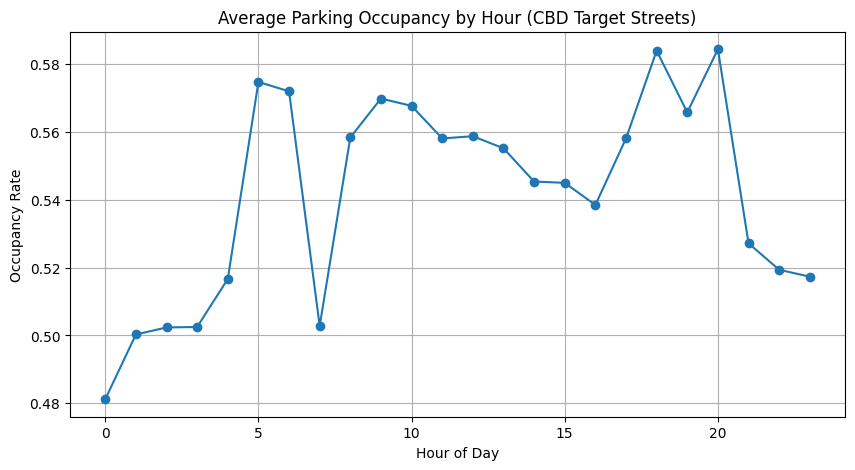


Top 10 Congestion Hotspots (by Street):
street_name
COLLINS STREET            0.566397
LITTLE BOURKE STREET      0.549975
LONSDALE STREET           0.546791
LITTLE COLLINS STREET     0.545289
LITTLE LONSDALE STREET    0.542440
ELIZABETH STREET          0.540844
BOURKE STREET             0.535977
Name: occupancy_binary, dtype: float64


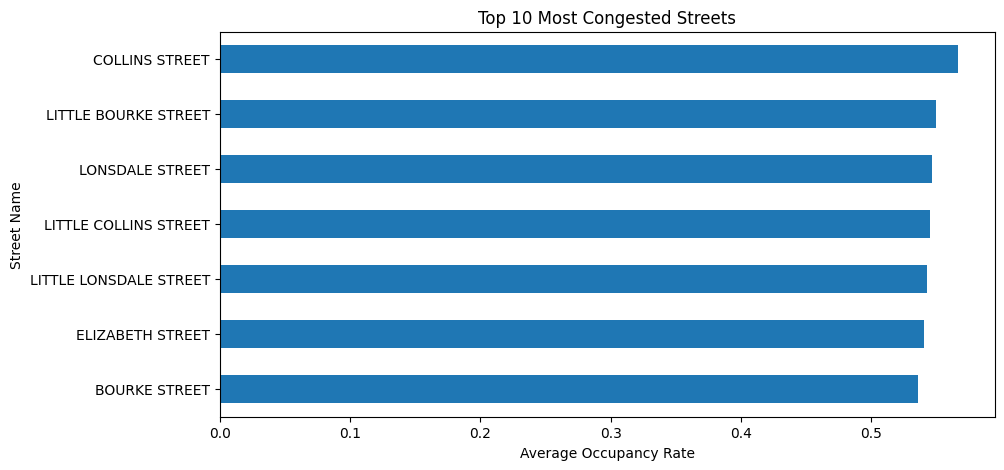

In [ ]:
# --- DEVELOPED BY: Atishay Jain ---
# Goal: Identify high-congestion 'hotspots' to provide strategic value to the City of Melbourne.

import matplotlib.pyplot as plt
import seaborn as sns

def analyse_parking_hotspots(df):
    """Visualising occupancy trends to identify peak demand periods."""

    df = df.copy()

    # Ensure occupancy is clean (safety reinforcement)
    df['occupancy_binary'] = df['occupancy_binary'].fillna(0)

    # 1. Peak Demand by Hour
    df['hour'] = df['arrival_time'].dt.hour
    hourly_occupancy = df.groupby('hour')['occupancy_binary'].mean()

    plt.figure(figsize=(10, 5))
    plt.plot(hourly_occupancy.index, hourly_occupancy.values, marker='o')
    plt.title('Average Parking Occupancy by Hour (CBD Target Streets)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Occupancy Rate')
    plt.grid(True)
    plt.show()

    # 2. Hotspot Identification: Top Streets
    street_usage = (
        df.groupby('street_name')['occupancy_binary']
        .mean()
        .sort_values(ascending=False)
    )

    top_streets = street_usage.head(10)

    print("\nTop 10 Congestion Hotspots (by Street):")
    print(top_streets)

    # Optional: Visualise hotspots (VERY good for marks)
    plt.figure(figsize=(10, 5))
    top_streets.sort_values().plot(kind='barh')
    plt.title('Top 10 Most Congested Streets')
    plt.xlabel('Average Occupancy Rate')
    plt.ylabel('Street Name')
    plt.show()

    return top_streets


# Execute Strategic EDA
hotspot_data = analyse_parking_hotspots(df_final)

In [4]:
# --- DEVELOPED BY: Yoginder Syal ---
# Goal: Build the technical pipeline for predictive forecasting.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

def prepare_model_features(df):
    """Engineering features for supervised learning."""

    df = df.copy()

    # Ensure time features exist
    df['hour'] = df['arrival_time'].dt.hour
    df['day_of_week'] = df['arrival_time'].dt.dayofweek

    # Encode bay_id (categorical → numeric)
    le = LabelEncoder()
    df['bay_id_encoded'] = le.fit_transform(df['bay_id'])

    # Feature set (IMPROVED)
    features = ['bay_id_encoded', 'hour', 'day_of_week']

    X = df[features]
    y = df['occupancy_binary']

    return train_test_split(X, y, test_size=0.2, random_state=42)


def train_baseline_model(X_train, X_test, y_train, y_test):
    """Training a baseline Random Forest to predict bay availability."""

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print(f"\nBaseline Model Accuracy: {accuracy_score(y_test, predictions):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    return model


# Execute Technical Model Setup
X_train, X_test, y_train, y_test = prepare_model_features(df_final)
baseline_model = train_baseline_model(X_train, X_test, y_train, y_test)


Baseline Model Accuracy: 49.94%

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.23      0.30    222647
           1       0.53      0.72      0.61    270272

    accuracy                           0.50    492919
   macro avg       0.47      0.48      0.45    492919
weighted avg       0.47      0.50      0.47    492919

